In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")

print(nav.shape)

nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


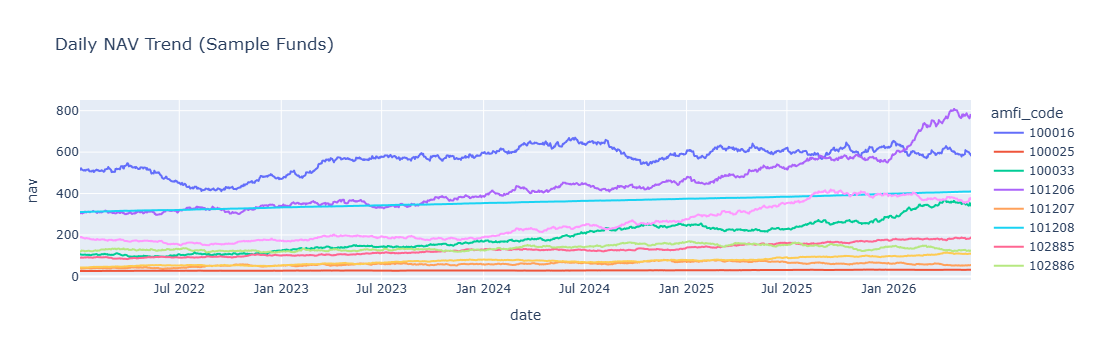

In [4]:
nav["date"] = pd.to_datetime(nav["date"])

sample_funds = nav["amfi_code"].unique()[:10]

nav_sample = nav[
    nav["amfi_code"].isin(sample_funds)
]

fig = px.line(
    nav_sample,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (Sample Funds)"
)

fig.show()

In [5]:
performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_clean.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

print("All datasets loaded")

All datasets loaded


In [6]:
print(aum.columns.tolist())
print(sip.columns.tolist())
print(category.columns.tolist())
print(folio.columns.tolist())
print(portfolio.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
['month', 'category', 'net_inflow_crore']
['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


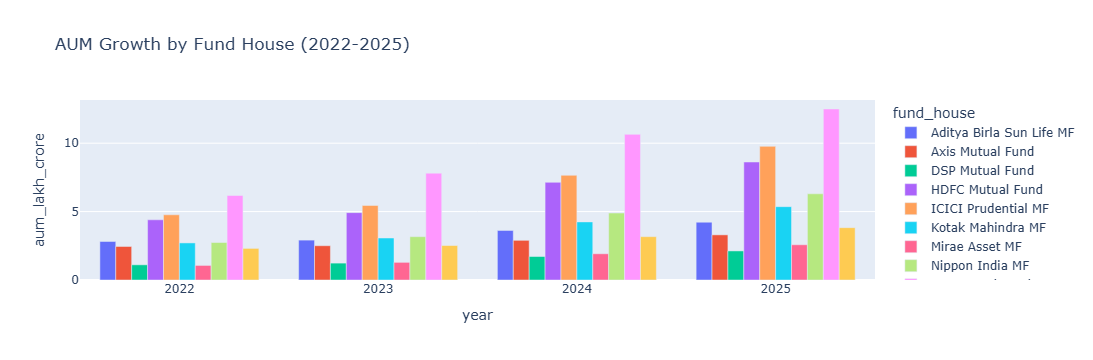

In [7]:
import plotly.express as px

aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

yearly_aum = aum.groupby(
    ["year", "fund_house"]
)["aum_lakh_crore"].mean().reset_index()

fig = px.bar(
    yearly_aum,
    x="year",
    y="aum_lakh_crore",
    color="fund_house",
    barmode="group",
    title="AUM Growth by Fund House (2022-2025)"
)

fig.show()

In [10]:
pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Shashi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [12]:
pip install --upgrade kaleido

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Shashi\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nav = pd.read_csv("data/processed/02_nav_history_clean.csv")

performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
transactions = pd.read_csv("data/processed/08_investor_transactions_clean.csv")
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("data/raw/05_category_inflows.csv")
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

In [3]:
aum["date"] = pd.to_datetime(aum["date"])

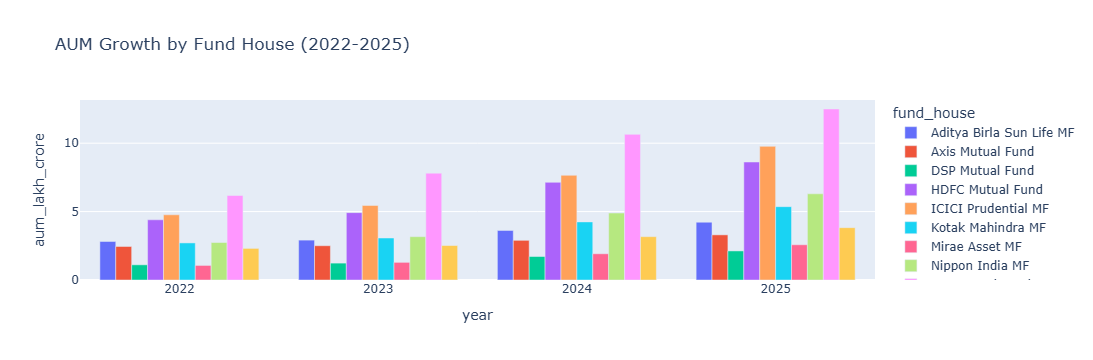

In [8]:
fig.write_image("AUM_Growth.png")

In [9]:
fig.write_image("AUM_Growth.png")

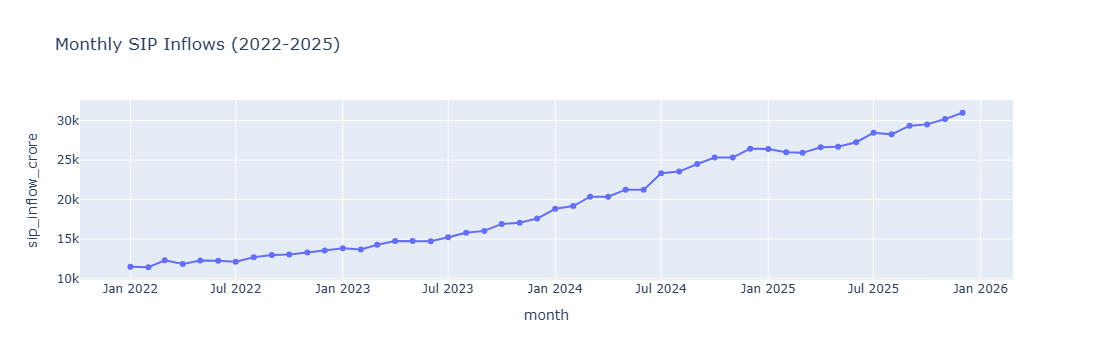

In [10]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022-2025)",
    markers=True
)

fig.show()

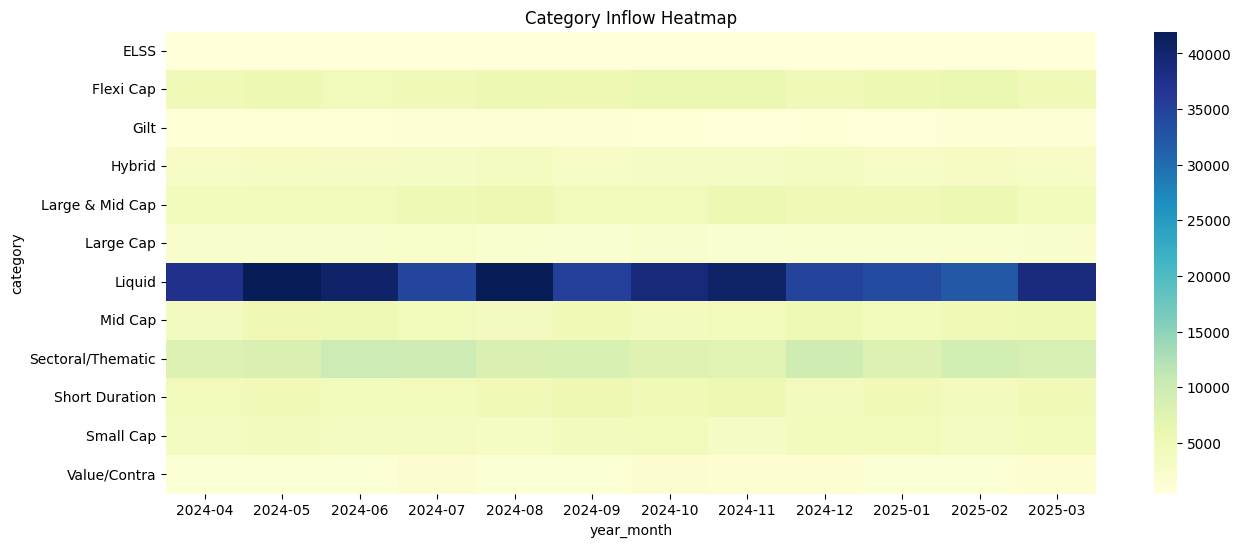

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

category["month"] = pd.to_datetime(category["month"])
category["year_month"] = category["month"].dt.strftime("%Y-%m")

heatmap_data = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="year_month",
    aggfunc="sum"
)

plt.figure(figsize=(15,6))
sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.title("Category Inflow Heatmap")
plt.show()

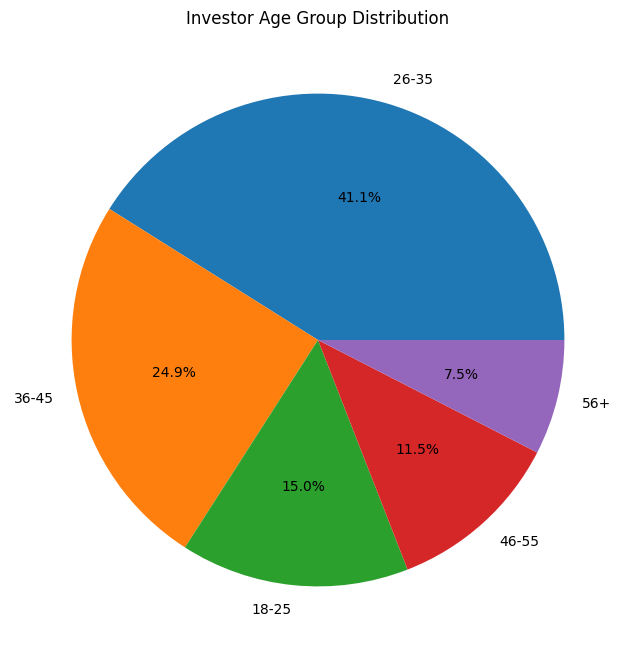

In [12]:
age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")
plt.show()

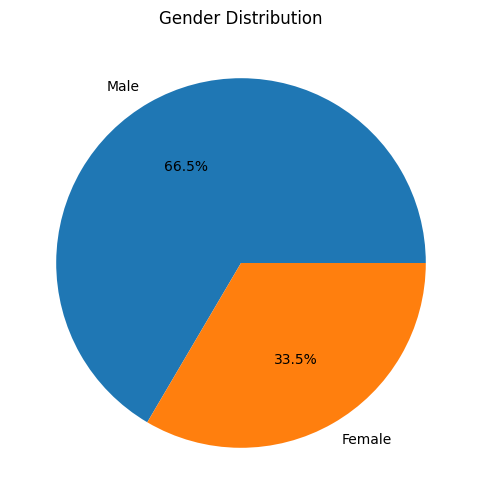

In [13]:
gender_counts = transactions["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

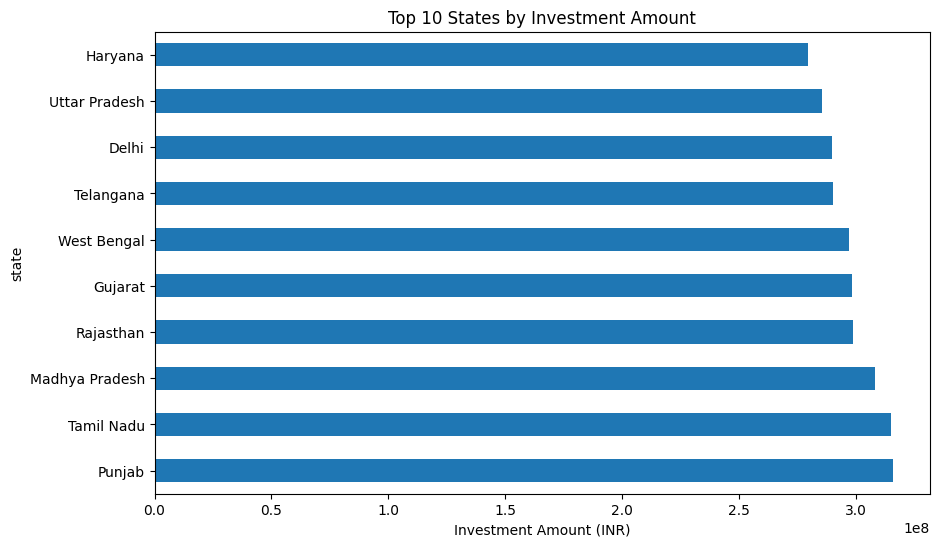

In [14]:
state_sip = transactions.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
state_sip.plot(kind="barh")
plt.title("Top 10 States by Investment Amount")
plt.xlabel("Investment Amount (INR)")
plt.show()

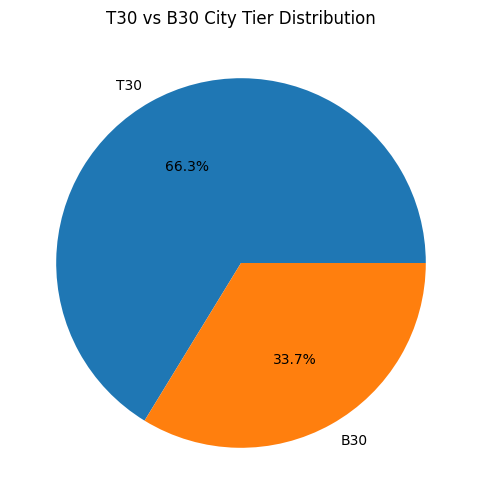

In [15]:
city_tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(city_tier, labels=city_tier.index, autopct="%1.1f%%")
plt.title("T30 vs B30 City Tier Distribution")
plt.show()

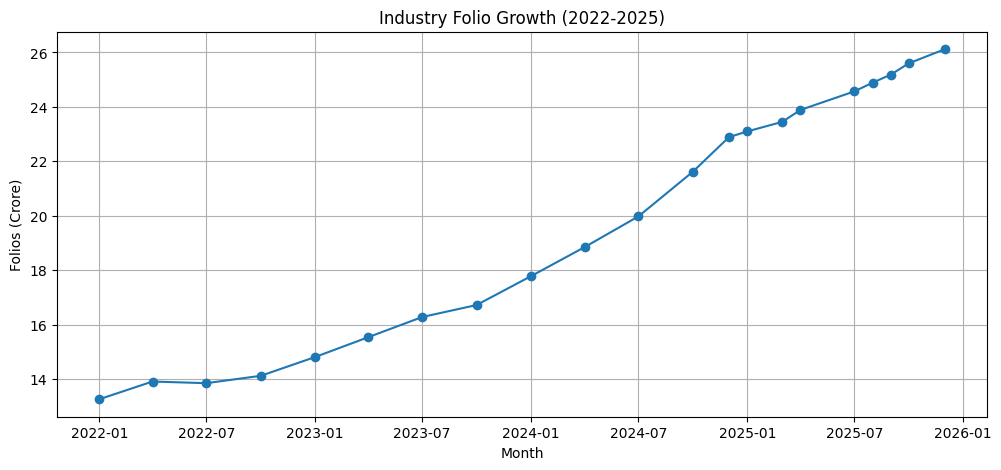

In [16]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))
plt.plot(folio["month"], folio["total_folios_crore"], marker="o")
plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.grid(True)
plt.show()

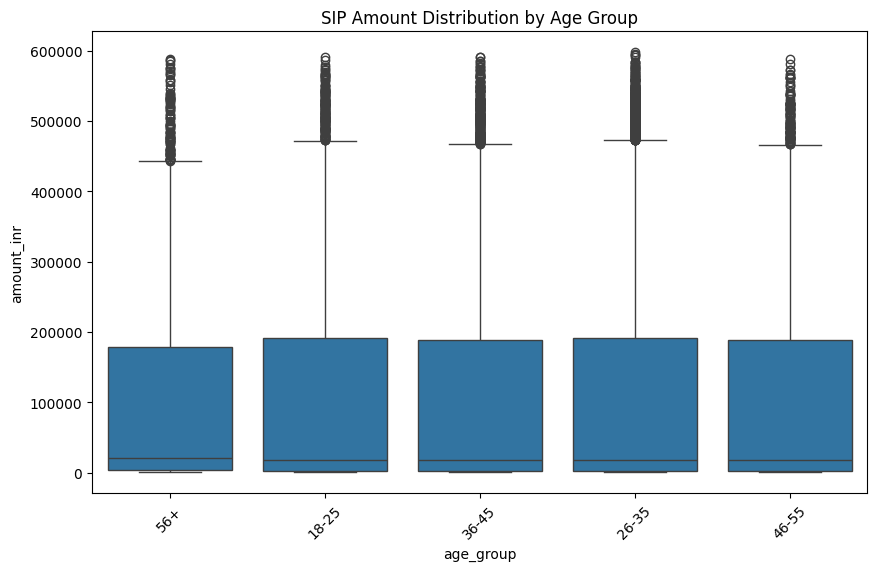

In [17]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.title("SIP Amount Distribution by Age Group")
plt.xticks(rotation=45)
plt.show()

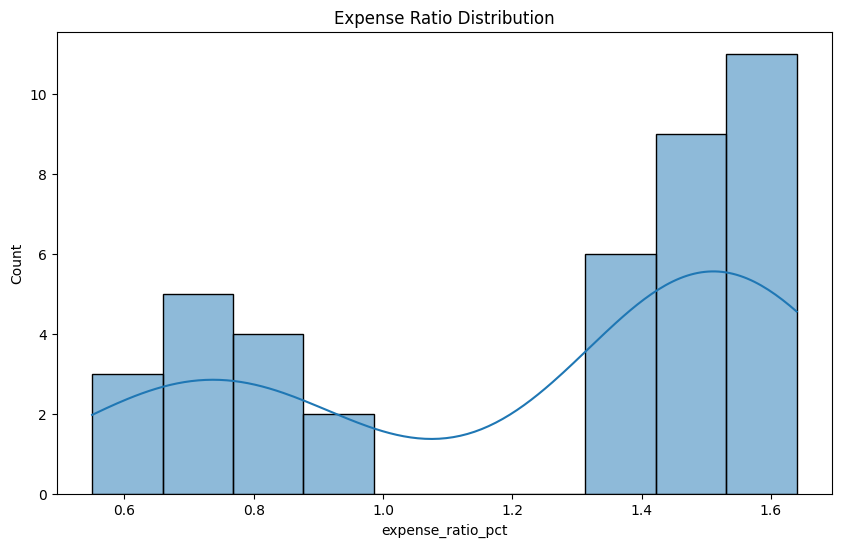

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)
plt.title("Expense Ratio Distribution")
plt.show()

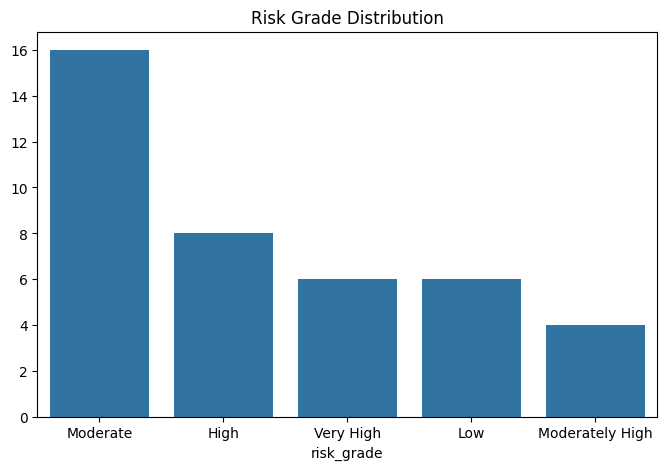

In [19]:
risk = performance["risk_grade"].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(
    x=risk.index,
    y=risk.values
)
plt.title("Risk Grade Distribution")
plt.show()

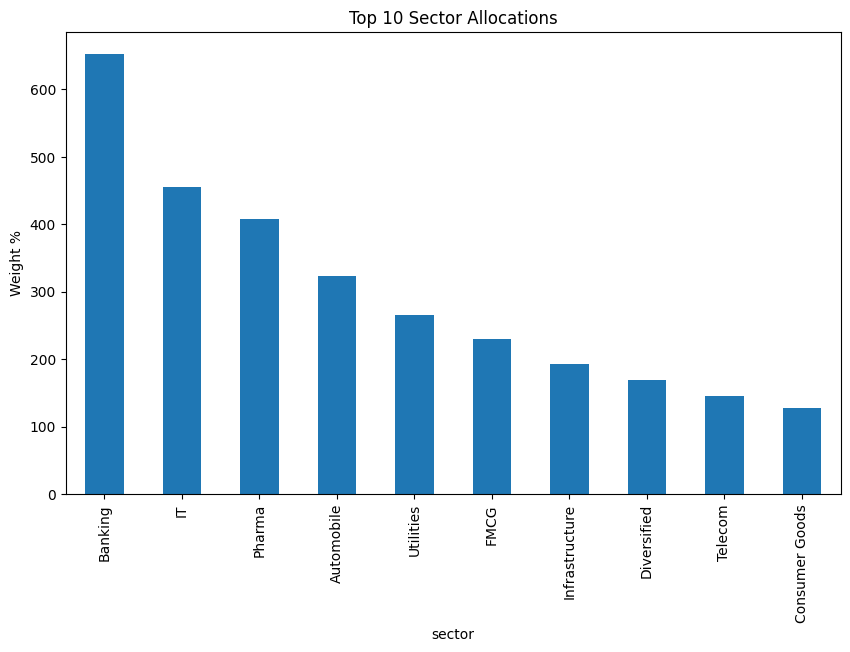

In [20]:
sector = portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sector.head(10).plot(kind="bar")
plt.title("Top 10 Sector Allocations")
plt.ylabel("Weight %")
plt.show()

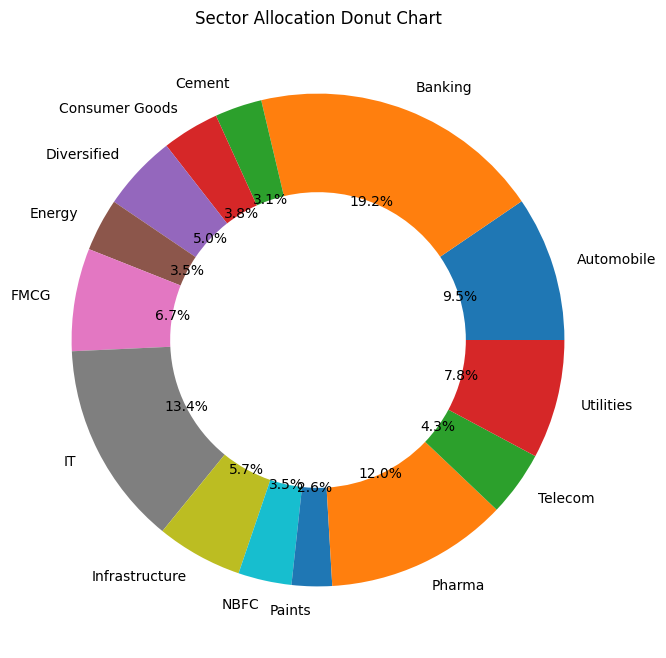

In [21]:
sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)
plt.title("Sector Allocation Donut Chart")
plt.show()

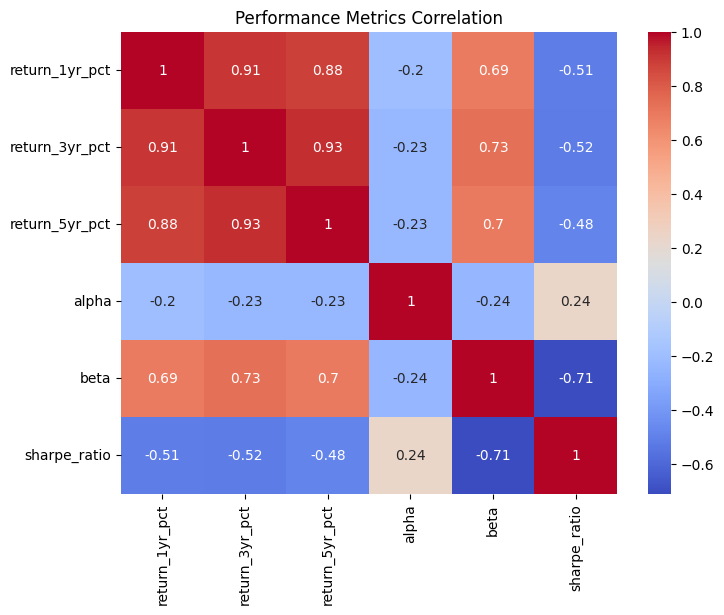

In [22]:
corr_cols = [
    "return_1yr_pct",
    "return_3yr_pct",
    "return_5yr_pct",
    "alpha",
    "beta",
    "sharpe_ratio"
]

corr = performance[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Performance Metrics Correlation")
plt.show()

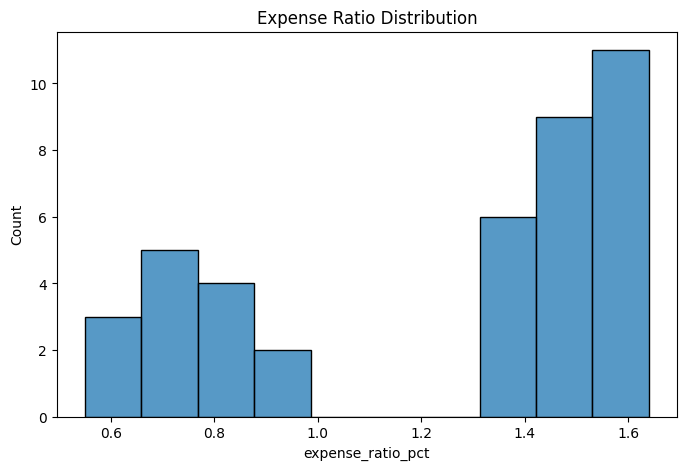

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(performance["expense_ratio_pct"], bins=10)
plt.title("Expense Ratio Distribution")
plt.show()

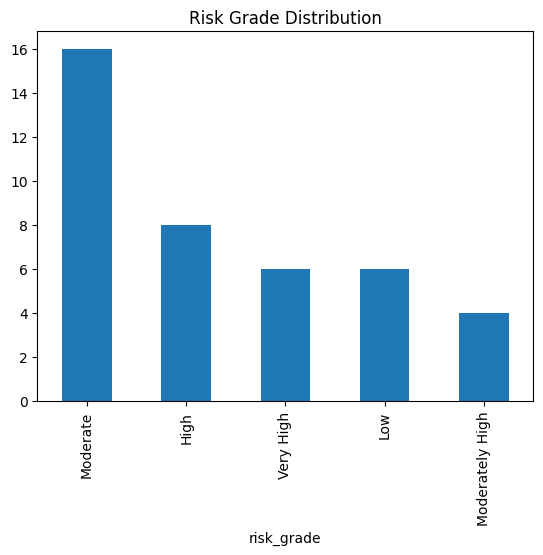

In [24]:
performance["risk_grade"].value_counts().plot(kind="bar")
plt.title("Risk Grade Distribution")
plt.show()

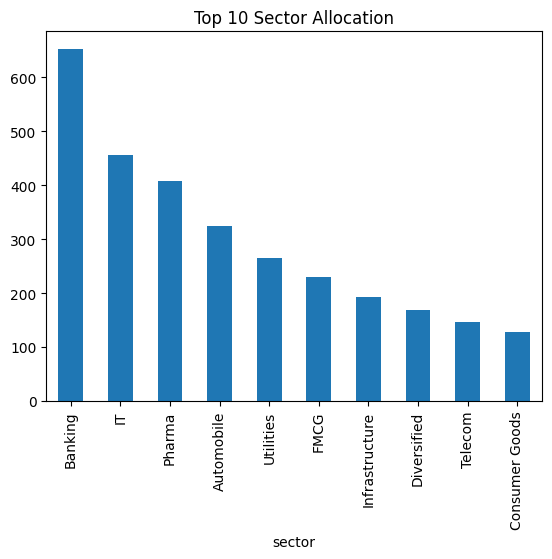

In [25]:
portfolio.groupby("sector")["weight_pct"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 Sector Allocation")
plt.show()

In [26]:
plt.savefig("heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [27]:
plt.savefig("gender_distribution.png")

<Figure size 640x480 with 0 Axes>

In [28]:
import os
print(os.listdir())

['.git', '.ipynb_checkpoints', 'amfi_validation.py', 'AUM_Growth.png', 'bluestock_mf.db', 'clean_nav.py', 'clean_performance.py', 'clean_transaction.py', 'dashboard', 'data', 'data_dictionary.md', 'data_ingestion.py', 'EDA_Analysis.ipynb', 'fund_master_analysis.py', 'gender_distribution.png', 'heatmap.png', 'live_nav_fetch.py', 'load_to_sqlite.py', 'notebooks', 'queries.sql', 'report.txt', 'reports', 'requirements.txt', 'schema.sql', 'sql']
